<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/Paper-Soyuz-ISS/blob/main/SPACEDOS_ISS_transition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS – ISS launch phase comparison (2019 vs 2020)

Tento notebook načítá již zkorigované CSV soubory `SPACEDOS_ISS2019_corrected.csv` a `SPACEDOS_ISS2020_corrected.csv` z Google Drive a vykresluje **flux jako funkci času** pro prvních ~7 dní každé mise, se zvýrazněnými událostmi až po **docking**.

**Optimalizace pro Colab:**
- načítají se pouze sloupce `corr_time`, `flux`, `ddsi` (ne celé spektrum)
- pomocí `nrows` se načte jen prvních ~7 dní dat (přibližně 60480 řádků při 10s integraci)

## Klíčové události

**Soyuz MS-15 (2019)**
- Launch: 25.09.2019, 13:57:42.701 UTC (Bajkonur, Site 1)
- Docking: 25.09.2019, 19:42:40 UTC (Poisk)

**Soyuz MS-17 (2020)**
- Launch: 14.10.2020, 05:45:04 UTC (Bajkonur, Site 31/6)
- Docking: 14.10.2020, 08:48:43 UTC (Rassvet) — 2-orbit ultrafast rendezvous

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
import gdown
%matplotlib inline

## 1. Stažení dat z Google Drive

In [3]:
# Google Drive file IDs
FILE_ID_2019 = "1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g"   # SPACEDOS_ISS2019_corrected.csv
FILE_ID_2020 = "1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5"   # SPACEDOS_ISS2020_corrected.csv

gdown.download(f"https://drive.google.com/uc?id={FILE_ID_2019}", "iss2019.csv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={FILE_ID_2020}", "iss2020.csv", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g
From (redirected): https://drive.google.com/uc?id=1iNoPx-lP6MwSoZj_PMbKcX4QorqoFq0g&confirm=t&uuid=d511bb8c-8f17-4b4e-8061-91db1b2729a1
To: /content/iss2019.csv
100%|██████████| 951M/951M [00:15<00:00, 61.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5
From (redirected): https://drive.google.com/uc?id=1AA8k2UhesWp0x2KbCycyiJnCheM1HXJ5&confirm=t&uuid=39cc20b6-7821-46c7-b8bc-b55b20a86960
To: /content/iss2020.csv
100%|██████████| 344M/344M [00:05<00:00, 60.0MB/s]


'iss2020.csv'

## 2. Načtení dat (paměťově úsporně)

Pro 7 dnů při 10s integraci je ~60 480 řádků. Načteme s rezervou ~80 000 řádků pro každý rok a pouze potřebné sloupce.

In [5]:
# Pouze potřebné sloupce — žádné spektrum, šetří paměť
USE_COLS = ["corr_time", "flux", "ddsi"]

# Počet řádků – 7 dnů s rezervou (10s integrace -> 8640 řádků/den)
N_ROWS = 80_000

rc19 = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)
rc20 = pd.read_csv("iss2020.csv", usecols=USE_COLS, nrows=N_ROWS)

rc19["corr_time"] = pd.to_datetime(rc19["corr_time"][rc19["corr_time"].notna()], utc=True, format='mixed')
rc20["corr_time"] = pd.to_datetime(rc20["corr_time"], utc=True, format='mixed')

print("2019:", rc19.shape, "  rozsah:", rc19["corr_time"].min(), "→", rc19["corr_time"].max())
print("2020:", rc20.shape, "  rozsah:", rc20["corr_time"].min(), "→", rc20["corr_time"].max())
print("\nPaměť:")
print("  rc19:", rc19.memory_usage(deep=True).sum() / 1e6, "MB")
print("  rc20:", rc20.memory_usage(deep=True).sum() / 1e6, "MB")

/tmp/ipykernel_1626/2956688785.py:7: DtypeWarning: Columns (259) have mixed types. Specify dtype option on import or set low_memory=False.
  rc19 = pd.read_csv("iss2019.csv", usecols=USE_COLS, nrows=N_ROWS)


2019: (80000, 3)   rozsah: 2019-09-25 00:00:03.955000+00:00 → 2019-10-02 03:19:24.415000+00:00
2020: (80000, 3)   rozsah: 2020-10-13 08:03:04.437640+00:00 → 2020-10-23 04:24:33.455080+00:00

Paměť:
  rc19: 1.920132 MB
  rc20: 1.920132 MB


## 3. Definice klíčových událostí letu

Soyuz timeline – časy fází odhodu jsou referenční (T+ od startu, pro Soyuz-FG / Soyuz-2.1a typické hodnoty).

In [6]:
# Soyuz MS-15 (2019) — Soyuz-FG
events_2019 = {
    "Launch":              pd.Timestamp("2019-09-25 13:57:42.701", tz="UTC"),
    "Boosters sep\n(+01:58)":  pd.Timestamp("2019-09-25 13:59:40.501", tz="UTC"),  # Korolev cross
    "Fairing jett\n(+02:37)":  pd.Timestamp("2019-09-25 14:00:20.181", tz="UTC"),
    "Core stage sep\n(+04:47)": pd.Timestamp("2019-09-25 14:02:30.001", tz="UTC"),
    "S/C separation\n(+08:48)": pd.Timestamp("2019-09-25 14:06:30.961", tz="UTC"),
    "Docking":              pd.Timestamp("2019-09-25 19:42:40", tz="UTC"),
}

# Soyuz MS-17 (2020) — Soyuz-2.1a, 2-orbit ultrafast rendezvous
L20 = pd.Timestamp("2020-10-14 05:45:04", tz="UTC")
events_2020 = {
    "Launch":              L20,
    "Boosters sep\n(+01:58)":  L20 + pd.Timedelta(seconds=118),
    "Fairing jett\n(+02:37)":  L20 + pd.Timedelta(seconds=157),
    "Core stage sep\n(+04:47)": L20 + pd.Timedelta(seconds=287),
    "S/C separation\n(+08:48)": L20 + pd.Timedelta(seconds=528),
    "Docking":              pd.Timestamp("2020-10-14 08:48:43", tz="UTC"),
}

## 4. Helper na vykreslování událostí

In [7]:
def draw_events(ax, events, tmin, tmax, color='black'):
    """Vykreslí svislé čáry s popisky pro události, které spadají do [tmin, tmax]."""
    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        if tmin <= t <= tmax:
            ax.axvline(t, linestyle="--", linewidth=1, color=color, alpha=0.7)
            ax.text(t, ymax, name,
                    rotation=90, va="top", ha="right",
                    fontsize=9, color=color,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

## 5. Graf 1: První týden 2019 (Soyuz MS-15)

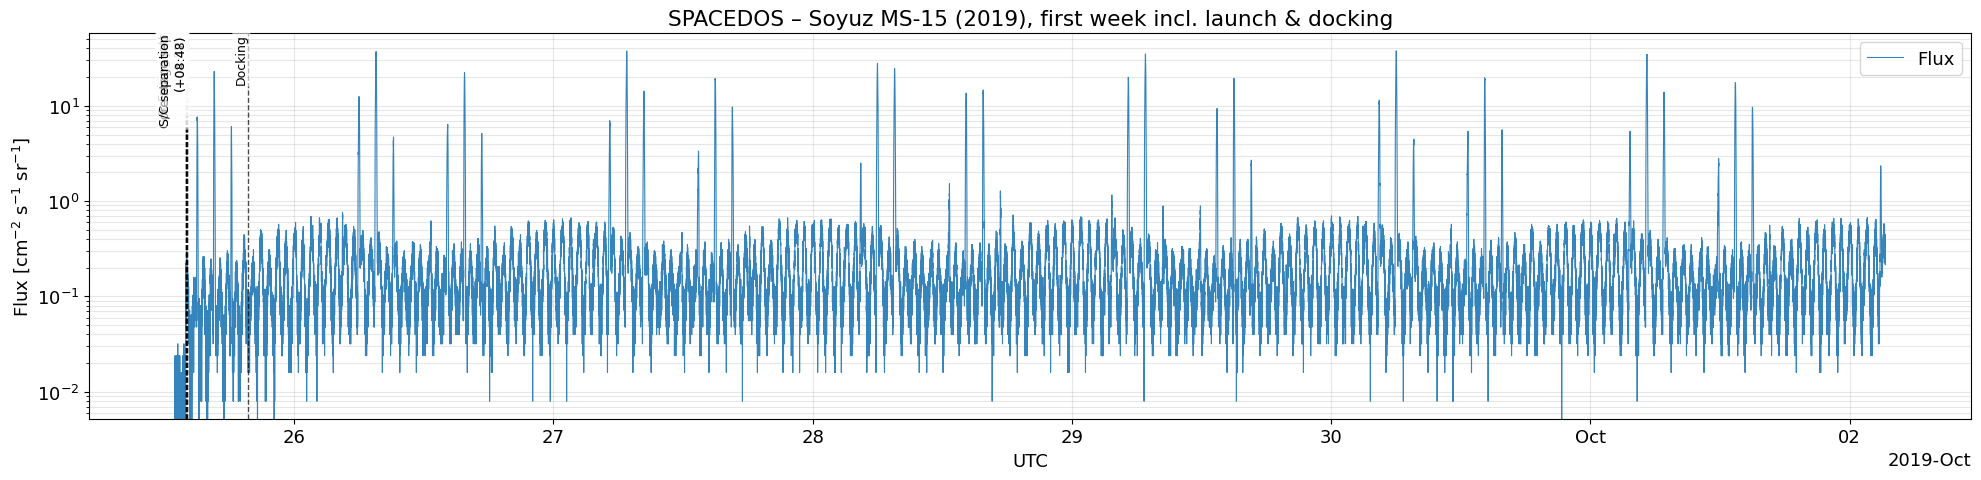

In [8]:
tmin = events_2019["Launch"] - pd.Timedelta(hours=1)
tmax = tmin + pd.Timedelta(days=7)

z = rc19.loc[(rc19["corr_time"] > tmin) & (rc19["corr_time"] < tmax)]

plt.figure(figsize=(20, 5))
matplotlib.rcParams.update({'font.size': 13})
ax = plt.gca()
ax.plot(z["corr_time"], z["flux"], color='tab:blue', lw=0.8, alpha=0.9, label="Flux")
ax.set_yscale('log')
ax.set_xlabel("UTC")
ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
ax.set_title("SPACEDOS – Soyuz MS-15 (2019), first week incl. launch & docking")
ax.grid(which='both', alpha=0.3)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

draw_events(ax, events_2019, tmin, tmax)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Graf 2: První týden 2020 (Soyuz MS-17)

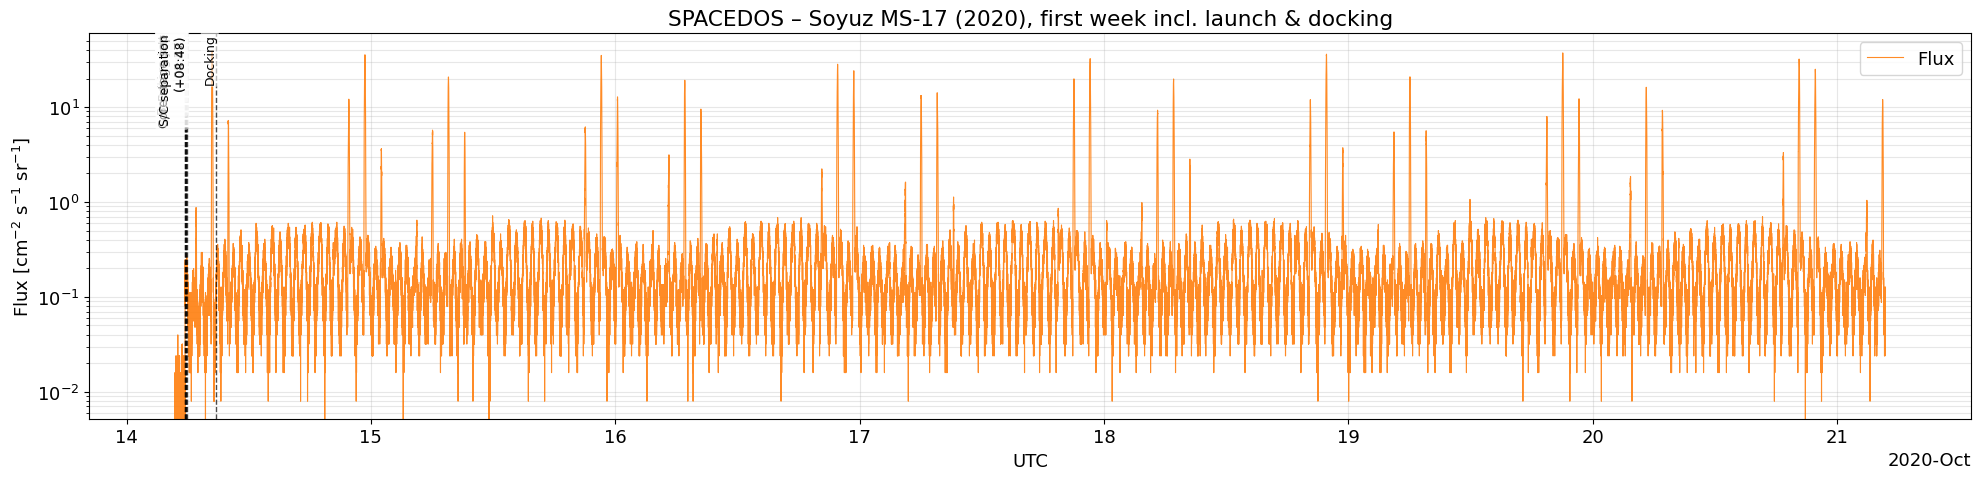

In [9]:
tmin = events_2020["Launch"] - pd.Timedelta(hours=1)
tmax = tmin + pd.Timedelta(days=7)

z = rc20.loc[(rc20["corr_time"] > tmin) & (rc20["corr_time"] < tmax)]

plt.figure(figsize=(20, 5))
matplotlib.rcParams.update({'font.size': 13})
ax = plt.gca()
ax.plot(z["corr_time"], z["flux"], color='tab:orange', lw=0.8, alpha=0.9, label="Flux")
ax.set_yscale('log')
ax.set_xlabel("UTC")
ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
ax.set_title("SPACEDOS – Soyuz MS-17 (2020), first week incl. launch & docking")
ax.grid(which='both', alpha=0.3)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))

draw_events(ax, events_2020, tmin, tmax)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 7. Graf 3: Detail launch → docking, obě mise vedle sebe

Časová osa je relativní k okamžiku startu (T+ hodiny), aby šly obě mise porovnat přímo.

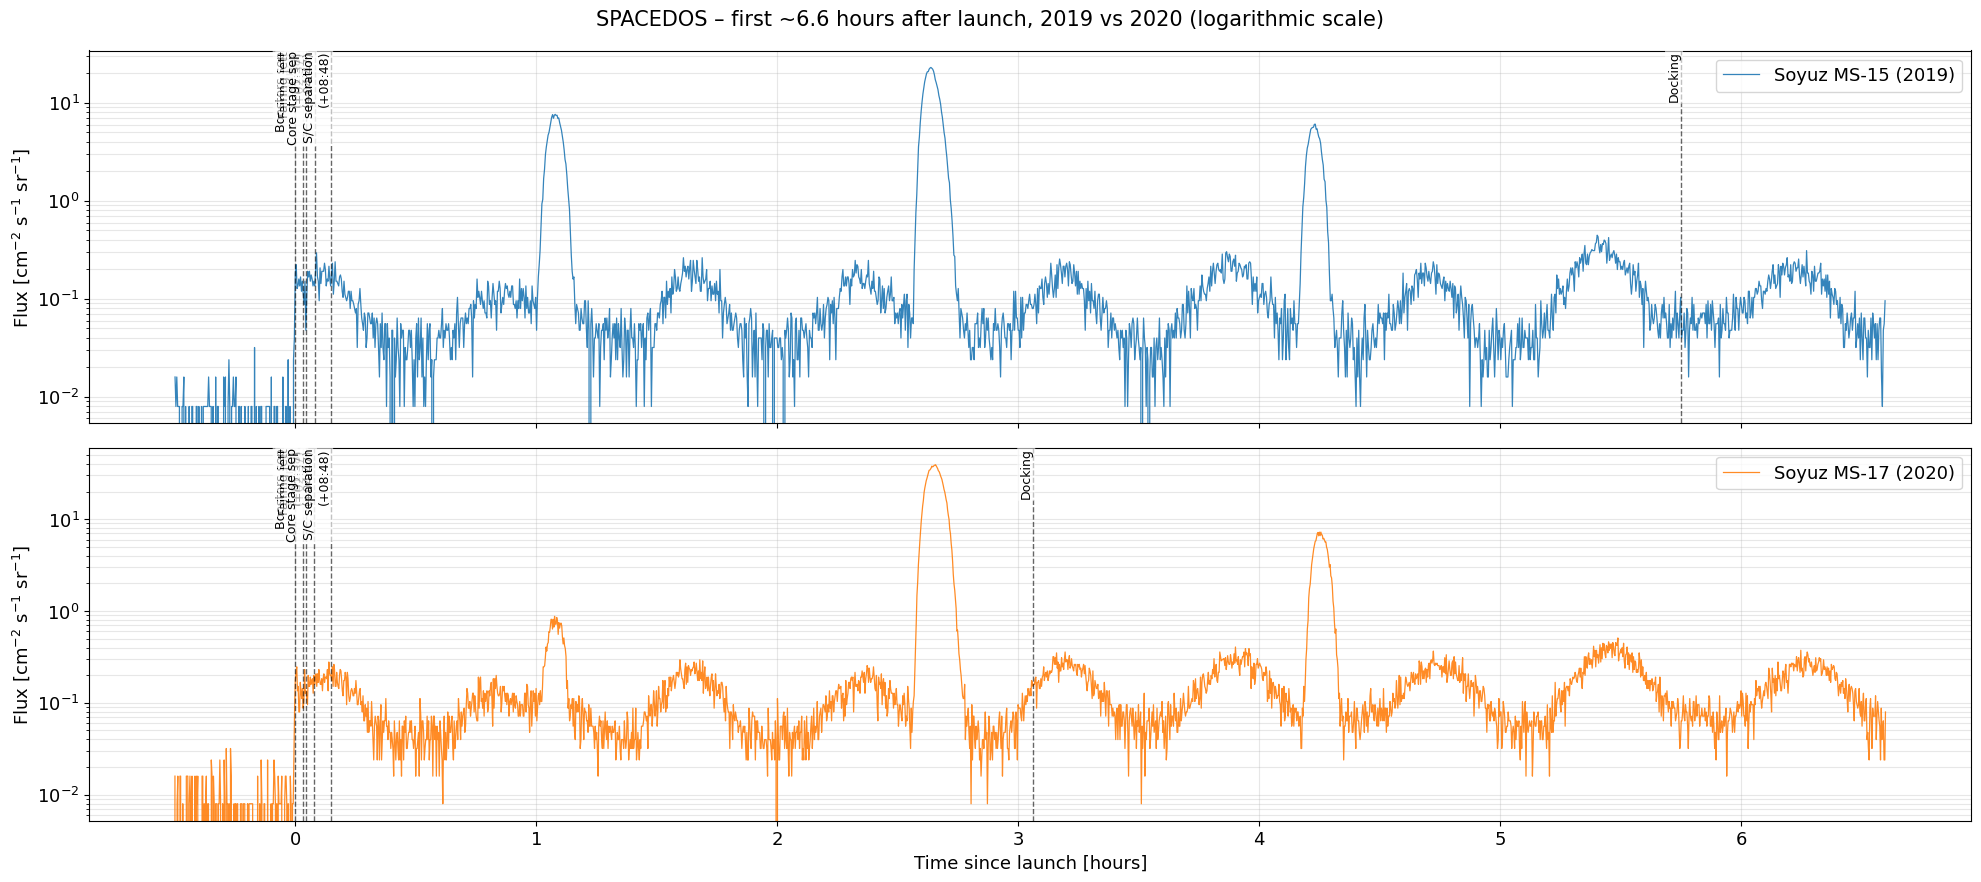

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(20, 9), sharex=True)
matplotlib.rcParams.update({'font.size': 13})

for ax, rc, events, color, label in [
    (axes[0], rc19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]:
    launch = events["Launch"]
    # tmax is now set to 6.6 hours after launch, not docking
    tmin = launch - pd.Timedelta(minutes=30)
    tmax = launch + pd.Timedelta(hours=6.6)

    z = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    # Relativní čas v hodinách od startu
    z["t_hours"] = (z["corr_time"] - launch).dt.total_seconds() / 3600.0

    ax.plot(z["t_hours"], z["flux"], color=color, lw=0.9, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')

    # události v relativním čase
    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        t_rel = (t - launch).total_seconds() / 3600.0
        # Update condition to display events within -0.5 to 6.6 hours relative to launch
        if -0.5 <= t_rel <= 6.6:
            ax.axvline(t_rel, linestyle="--", linewidth=1, color='black', alpha=0.6)
            ax.text(t_rel, ymax, name,
                    rotation=90, va="top", ha="right", fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

axes[1].set_xlabel("Time since launch [hours]")
fig.suptitle("SPACEDOS – first ~6.6 hours after launch, 2019 vs 2020 (logarithmic scale)", fontsize=15)
plt.tight_layout()
plt.show()

## 8. (volitelné) Detail prvních ~1 h po startu — průlet SAA

Logaritmicka osa pro tok, dobře vidět nárůst při průletu radiačním pásem v první hodině.

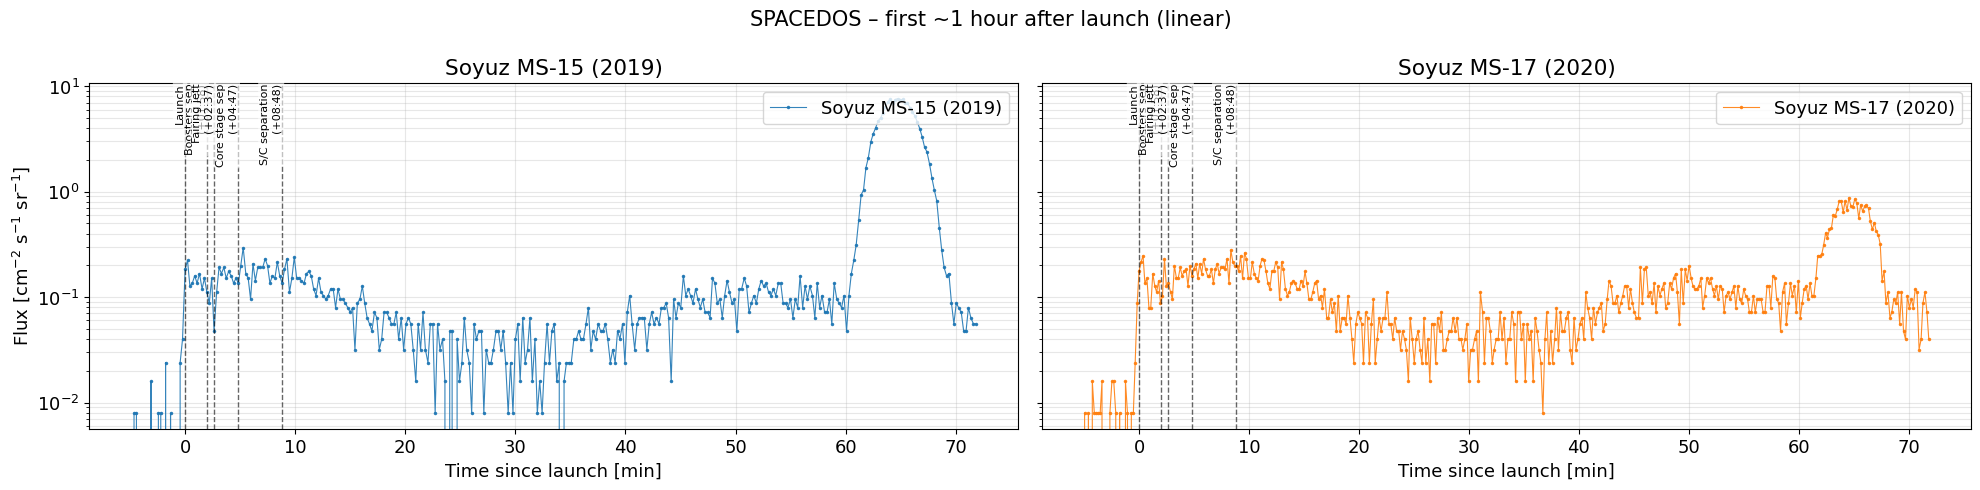

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)
matplotlib.rcParams.update({'font.size': 13})

for ax, rc, events, color, label in [
    (axes[0], rc19, events_2019, 'tab:blue',   "Soyuz MS-15 (2019)"),
    (axes[1], rc20, events_2020, 'tab:orange', "Soyuz MS-17 (2020)"),
]:
    launch = events["Launch"]
    tmin = launch - pd.Timedelta(minutes=5)
    tmax = launch + pd.Timedelta(hours=1.2)

    z = rc.loc[(rc["corr_time"] > tmin) & (rc["corr_time"] < tmax)].copy()
    z["t_min"] = (z["corr_time"] - launch).dt.total_seconds() / 60.0

    ax.plot(z["t_min"], z["flux"], marker='.', ms=3, lw=0.8, color=color, alpha=0.9, label=label)
    ax.set_yscale('log')
    ax.set_xlabel("Time since launch [min]")
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(label)

    ymin, ymax = ax.get_ylim()
    for name, t in events.items():
        t_rel = (t - launch).total_seconds() / 60.0
        if -5 <= t_rel <= 72:
            ax.axvline(t_rel, linestyle="--", linewidth=1, color='black', alpha=0.6)
            ax.text(t_rel, ymax, name,
                    rotation=90, va="top", ha="right", fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

axes[0].set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]")
fig.suptitle("SPACEDOS – first ~1 hour after launch (linear)", fontsize=15)
plt.tight_layout()
plt.show()